In [5]:
import urllib.request as rq
import urllib.parse as up
import matplotlib.pyplot as plt
import numpy as np
import json

# Extraction

In [3]:
# URL del Dataseth
URL = "https://archive-api.open-meteo.com/v1/archive"

# Parámetros para la consulta
parametros = {
    "latitude": -14.0678,
    "longitude": -75.7286,
    "start_date": "2020-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,rain_sum",
    "timezone": "America/Lima"
}

# Construir la URL con los parámetros
url_con_parametros = f"{URL}?{up.urlencode(parametros)}"

# Realizar la solicitud HTTP

def extract_data_from_url(data_url):
    try:
        with rq.urlopen(data_url) as response:
            if response.status == 200:
                body = response.read()
                data = json.loads(body.decode('utf-8'))
                return data

            else:
                return f"Error codigo: {response.status}"
            
    except Exception as e:
        return f"Error al realizar la solicitud: {e}"

# Transform

## Diagrama de Caja y Bigotes

Registros validos: 2192
Registros descartados por nulos: 0



/tmp/ipykernel_3961/1070445193.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


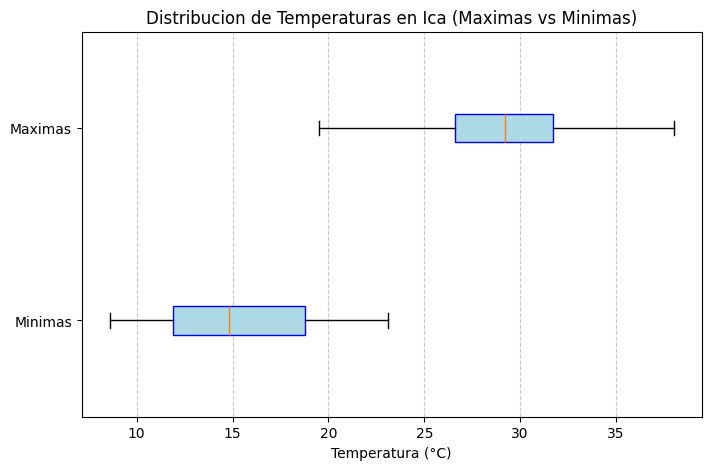

[{'fecha': '2020-01-01',
  'temp_maxima': 29.6,
  'temp_minima': 20.7,
  'lluvia_mm': 0.1},
 {'fecha': '2020-01-02',
  'temp_maxima': 27.8,
  'temp_minima': 19.0,
  'lluvia_mm': 0.1},
 {'fecha': '2020-01-03',
  'temp_maxima': 31.3,
  'temp_minima': 19.4,
  'lluvia_mm': 0.0},
 {'fecha': '2020-01-04',
  'temp_maxima': 33.4,
  'temp_minima': 19.7,
  'lluvia_mm': 0.0},
 {'fecha': '2020-01-05',
  'temp_maxima': 31.9,
  'temp_minima': 19.9,
  'lluvia_mm': 0.3},
 {'fecha': '2020-01-06',
  'temp_maxima': 31.5,
  'temp_minima': 19.4,
  'lluvia_mm': 0.0},
 {'fecha': '2020-01-07',
  'temp_maxima': 32.8,
  'temp_minima': 18.5,
  'lluvia_mm': 0.3},
 {'fecha': '2020-01-08',
  'temp_maxima': 30.6,
  'temp_minima': 21.0,
  'lluvia_mm': 0.6},
 {'fecha': '2020-01-09',
  'temp_maxima': 31.4,
  'temp_minima': 20.4,
  'lluvia_mm': 0.0},
 {'fecha': '2020-01-10',
  'temp_maxima': 32.3,
  'temp_minima': 17.6,
  'lluvia_mm': 0.0},
 {'fecha': '2020-01-11',
  'temp_maxima': 31.2,
  'temp_minima': 17.3,
  'lluvia

In [ ]:
def _graficar_diagrama_caja(minimas: list[float], maximas: list[float]) -> None:
    """
    Genera el diagrama de caja y bigotes comparando temperaturas mínimas y máximas.
    Los puntos fuera de los bigotes son outliers visuales, no se eliminan del dataset.
    """
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [minimas, maximas],
        vert=False,
        patch_artist=True,
        labels=["Minimas", "Maximas"],
        boxprops=dict(facecolor="lightblue", color="blue"),
        flierprops=dict(marker="o", markerfacecolor="red", markersize=6, linestyle="none"),
    )
    plt.title("Distribucion de Temperaturas en Ica (Maximas vs Minimas)")
    plt.xlabel("Temperatura (°C)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()


def diagrama_caja_bigotes(datos_api: dict) -> list[dict] | str:
    """
    Procesa datos meteorológicos diarios descartando únicamente registros con valores
    nulos (errores de sensor o API). Los valores atípicos se conservan porque pueden
    representar temperaturas reales extremas propias de la zona geográfica.

    El diagrama de caja y bigotes generado permite identificar visualmente
    esos valores atípicos sin eliminarlos del dataset.

    Args:
        datos_api: Diccionario con clave "daily" que contiene listas de:
                   time, temperature_2m_max, temperature_2m_min, rain_sum.

    Returns:
        Lista de registros válidos como dicts con claves:
        fecha, temp_maxima, temp_minima, lluvia_mm.
        Retorna un string de error si la entrada no es válida.
    """
    if not isinstance(datos_api, dict) or "daily" not in datos_api:
        return "Datos de entrada no validos."

    datos_diarios = datos_api["daily"]
    fechas = datos_diarios["time"]
    maximas = datos_diarios["temperature_2m_max"]
    minimas = datos_diarios["temperature_2m_min"]
    lluvias = datos_diarios["rain_sum"]

    registros_validos = []
    registros_descartados = 0

    for fecha, t_max, t_min, lluvia in zip(fechas, maximas, minimas, lluvias):
        if any(valor is None for valor in (t_max, t_min, lluvia)):
            registros_descartados += 1
            continue

        registros_validos.append({
            "fecha": fecha,
            "temp_maxima": float(t_max),
            "temp_minima": float(t_min),
            "lluvia_mm": float(lluvia),
        })

    print(f"Registros validos: {len(registros_validos)}")
    print(f"Registros descartados por nulos: {registros_descartados}\n")

    maximas_validas = [r["temp_maxima"] for r in registros_validos]
    minimas_validas = [r["temp_minima"] for r in registros_validos]

    _graficar_diagrama_caja(minimas_validas, maximas_validas)

    return registros_validos


diagrama_caja_bigotes(extract_data_from_url(url_con_parametros))